In [4]:
import os
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np

# -------------------------- 参数配置 --------------------------
REFERENCE_DIR = "../dataset/groundtruth"  # 参考图像路径
GEN_IMAGE_DIR = "../pix2pix_code04/generated_results_dc_hed_contour_clean_"  # 生成图像路径
TARGET_SIZE = 300  # 统一目标尺寸（根据你的需求设置，如300x300）
BATCH_SIZE = 16

# -------------------------- 成对数据集类（确保尺寸一致） --------------------------
class PairedDataset(Dataset):
    def __init__(self, ref_dir, gen_dir, transform):
        self.ref_paths = sorted([
            os.path.join(ref_dir, f)
            for f in os.listdir(ref_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        self.gen_paths = sorted([
            os.path.join(gen_dir, f)
            for f in os.listdir(gen_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        assert len(self.ref_paths) == len(self.gen_paths), "参考图与生成图数量必须相同！"
        self.transform = transform
        print(f"加载 {len(self.ref_paths)} 对图像，将统一缩放到 {TARGET_SIZE}x{TARGET_SIZE}")

    def __len__(self):
        return len(self.ref_paths)

    def __getitem__(self, idx):
        # 读取图像
        ref_img = Image.open(self.ref_paths[idx]).convert("RGB")
        gen_img = Image.open(self.gen_paths[idx]).convert("RGB")
        # 应用相同的预处理（包括缩放）
        return self.transform(ref_img), self.transform(gen_img)

# -------------------------- PSNR计算函数（添加尺寸检查） --------------------------
def compute_psnr(ref_img, gen_img):
    """计算PSNR，确保输入图像尺寸完全一致"""
    # 转换为numpy数组（[H, W, 3]）
    ref_np = (ref_img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    gen_np = (gen_img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    # 检查尺寸是否一致
    assert ref_np.shape == gen_np.shape, \
        f"图像尺寸不匹配：参考图{ref_np.shape}，生成图{gen_np.shape}！"

    # 计算MSE和PSNR
    mse = np.mean((ref_np - gen_np) **2)
    return 10 * np.log10((255** 2) / mse) if mse != 0 else float('inf')

# -------------------------- 主运行逻辑（强制统一尺寸） --------------------------
if __name__ == "__main__":
    # 图像预处理：强制缩放到TARGET_SIZE（确保两者尺寸一致）
    transform = transforms.Compose([
        transforms.Resize((TARGET_SIZE, TARGET_SIZE)),  # 关键：统一尺寸
        transforms.ToTensor()  # 输出：[3, TARGET_SIZE, TARGET_SIZE]
    ])

    # 加载成对数据
    dataset = PairedDataset(REFERENCE_DIR, GEN_IMAGE_DIR, transform)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    # 计算PSNR
    psnr_list = []
    for ref_imgs, gen_imgs in dataloader:
        for ref, gen in zip(ref_imgs, gen_imgs):
            psnr = compute_psnr(ref, gen)
            psnr_list.append(psnr)

    print(f"统一尺寸 {TARGET_SIZE}x{TARGET_SIZE} 后的平均PSNR: {np.mean(psnr_list):.2f} dB")

加载 10076 对图像，将统一缩放到 300x300
统一尺寸 300x300 后的平均PSNR: 33.02 dB


In [6]:
import os
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np

# -------------------------- 参数配置 --------------------------
REFERENCE_DIR = "../dataset/groundtruth"  # 参考图像路径
GEN_IMAGE_DIR = "../FlexIcon/test_output/batch_test"  # 生成图像路径
TARGET_SIZE = 300  # 统一目标尺寸
BATCH_SIZE = 16
SAVE_RESULT_PATH = "../FlexIcon/test_output/batch_test/psnr_results.npz"  # 保存PSNR结果的文件路径

# -------------------------- 成对数据集类（新增文件名返回） --------------------------
class PairedDataset(Dataset):
    def __init__(self, ref_dir, gen_dir, transform):
        # 筛选并排序图像文件
        self.ref_paths = sorted([
            os.path.join(ref_dir, f)
            for f in os.listdir(ref_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        self.gen_paths = sorted([
            os.path.join(gen_dir, f)
            for f in os.listdir(gen_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        # 校验样本数量匹配
        assert len(self.ref_paths) == len(self.gen_paths), "参考图与生成图数量必须相同！"
        # 提取文件名，用于后续数据关联
        self.filenames = [os.path.basename(p) for p in self.ref_paths]
        self.transform = transform
        print(f"加载 {len(self.ref_paths)} 对图像，将统一缩放到 {TARGET_SIZE}x{TARGET_SIZE}")

    def __len__(self):
        return len(self.ref_paths)

    def __getitem__(self, idx):
        # 读取图像
        ref_img = Image.open(self.ref_paths[idx]).convert("RGB")
        gen_img = Image.open(self.gen_paths[idx]).convert("RGB")
        # 返回：预处理后的图像 + 对应文件名
        return self.transform(ref_img), self.transform(gen_img), self.filenames[idx]

# -------------------------- PSNR计算函数（原逻辑完全保留） --------------------------
def compute_psnr(ref_img, gen_img):
    """计算PSNR，确保输入图像尺寸完全一致"""
    # 转换为numpy数组（[H, W, 3]）
    ref_np = (ref_img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    gen_np = (gen_img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    # 检查尺寸是否一致
    assert ref_np.shape == gen_np.shape, \
        f"图像尺寸不匹配：参考图{ref_np.shape}，生成图{gen_np.shape}！"

    # 计算MSE和PSNR
    mse = np.mean((ref_np - gen_np) ** 2)
    return 10 * np.log10((255** 2) / mse) if mse != 0 else float('inf')

# -------------------------- 主运行逻辑 --------------------------
if __name__ == "__main__":
    # 图像预处理：强制缩放到统一尺寸
    transform = transforms.Compose([
        transforms.Resize((TARGET_SIZE, TARGET_SIZE)),
        transforms.ToTensor()
    ])

    # 加载数据集
    dataset = PairedDataset(REFERENCE_DIR, GEN_IMAGE_DIR, transform)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    # 初始化存储列表
    psnr_scores = []
    img_filenames = []

    print("开始逐张计算 PSNR...")
    # 遍历批次计算
    for batch_idx, (ref_imgs, gen_imgs, filenames) in enumerate(dataloader):
        for ref, gen, fname in zip(ref_imgs, gen_imgs, filenames):
            psnr_val = compute_psnr(ref, gen)
            psnr_scores.append(psnr_val)
            img_filenames.append(fname)

        # 每10个批次打印一次进度
        if (batch_idx + 1) % 10 == 0:
            print(f"已处理 {batch_idx + 1} 个批次，累计计算 {len(psnr_scores)} 张图像")

    # 统计结果输出
    avg_psnr = np.mean(psnr_scores)
    print("-" * 50)
    print(f"总样本数：{len(psnr_scores)}")
    print(f"平均 PSNR：{avg_psnr:.2f} dB")
    print("-" * 50)

    # 保存数据：文件名 + PSNR分数 压缩存储
    np.savez_compressed(
        SAVE_RESULT_PATH,
        filenames=np.array(img_filenames, dtype=object),
        psnr=np.array(psnr_scores)
    )
    print(f"✅ 所有PSNR结果已保存至：{os.path.abspath(SAVE_RESULT_PATH)}")

加载 10076 对图像，将统一缩放到 300x300
开始逐张计算 PSNR...
已处理 10 个批次，累计计算 160 张图像
已处理 20 个批次，累计计算 320 张图像
已处理 30 个批次，累计计算 480 张图像
已处理 40 个批次，累计计算 640 张图像
已处理 50 个批次，累计计算 800 张图像
已处理 60 个批次，累计计算 960 张图像
已处理 70 个批次，累计计算 1120 张图像
已处理 80 个批次，累计计算 1280 张图像
已处理 90 个批次，累计计算 1440 张图像
已处理 100 个批次，累计计算 1600 张图像
已处理 110 个批次，累计计算 1760 张图像
已处理 120 个批次，累计计算 1920 张图像
已处理 130 个批次，累计计算 2080 张图像
已处理 140 个批次，累计计算 2240 张图像
已处理 150 个批次，累计计算 2400 张图像
已处理 160 个批次，累计计算 2560 张图像
已处理 170 个批次，累计计算 2720 张图像
已处理 180 个批次，累计计算 2880 张图像
已处理 190 个批次，累计计算 3040 张图像
已处理 200 个批次，累计计算 3200 张图像
已处理 210 个批次，累计计算 3360 张图像
已处理 220 个批次，累计计算 3520 张图像
已处理 230 个批次，累计计算 3680 张图像
已处理 240 个批次，累计计算 3840 张图像
已处理 250 个批次，累计计算 4000 张图像
已处理 260 个批次，累计计算 4160 张图像
已处理 270 个批次，累计计算 4320 张图像
已处理 280 个批次，累计计算 4480 张图像
已处理 290 个批次，累计计算 4640 张图像
已处理 300 个批次，累计计算 4800 张图像
已处理 310 个批次，累计计算 4960 张图像
已处理 320 个批次，累计计算 5120 张图像
已处理 330 个批次，累计计算 5280 张图像
已处理 340 个批次，累计计算 5440 张图像
已处理 350 个批次，累计计算 5600 张图像
已处理 360 个批次，累计计算 5760 张图像
已处理 370 个批次，累计计算 5920 张图像
已处理 380 个批

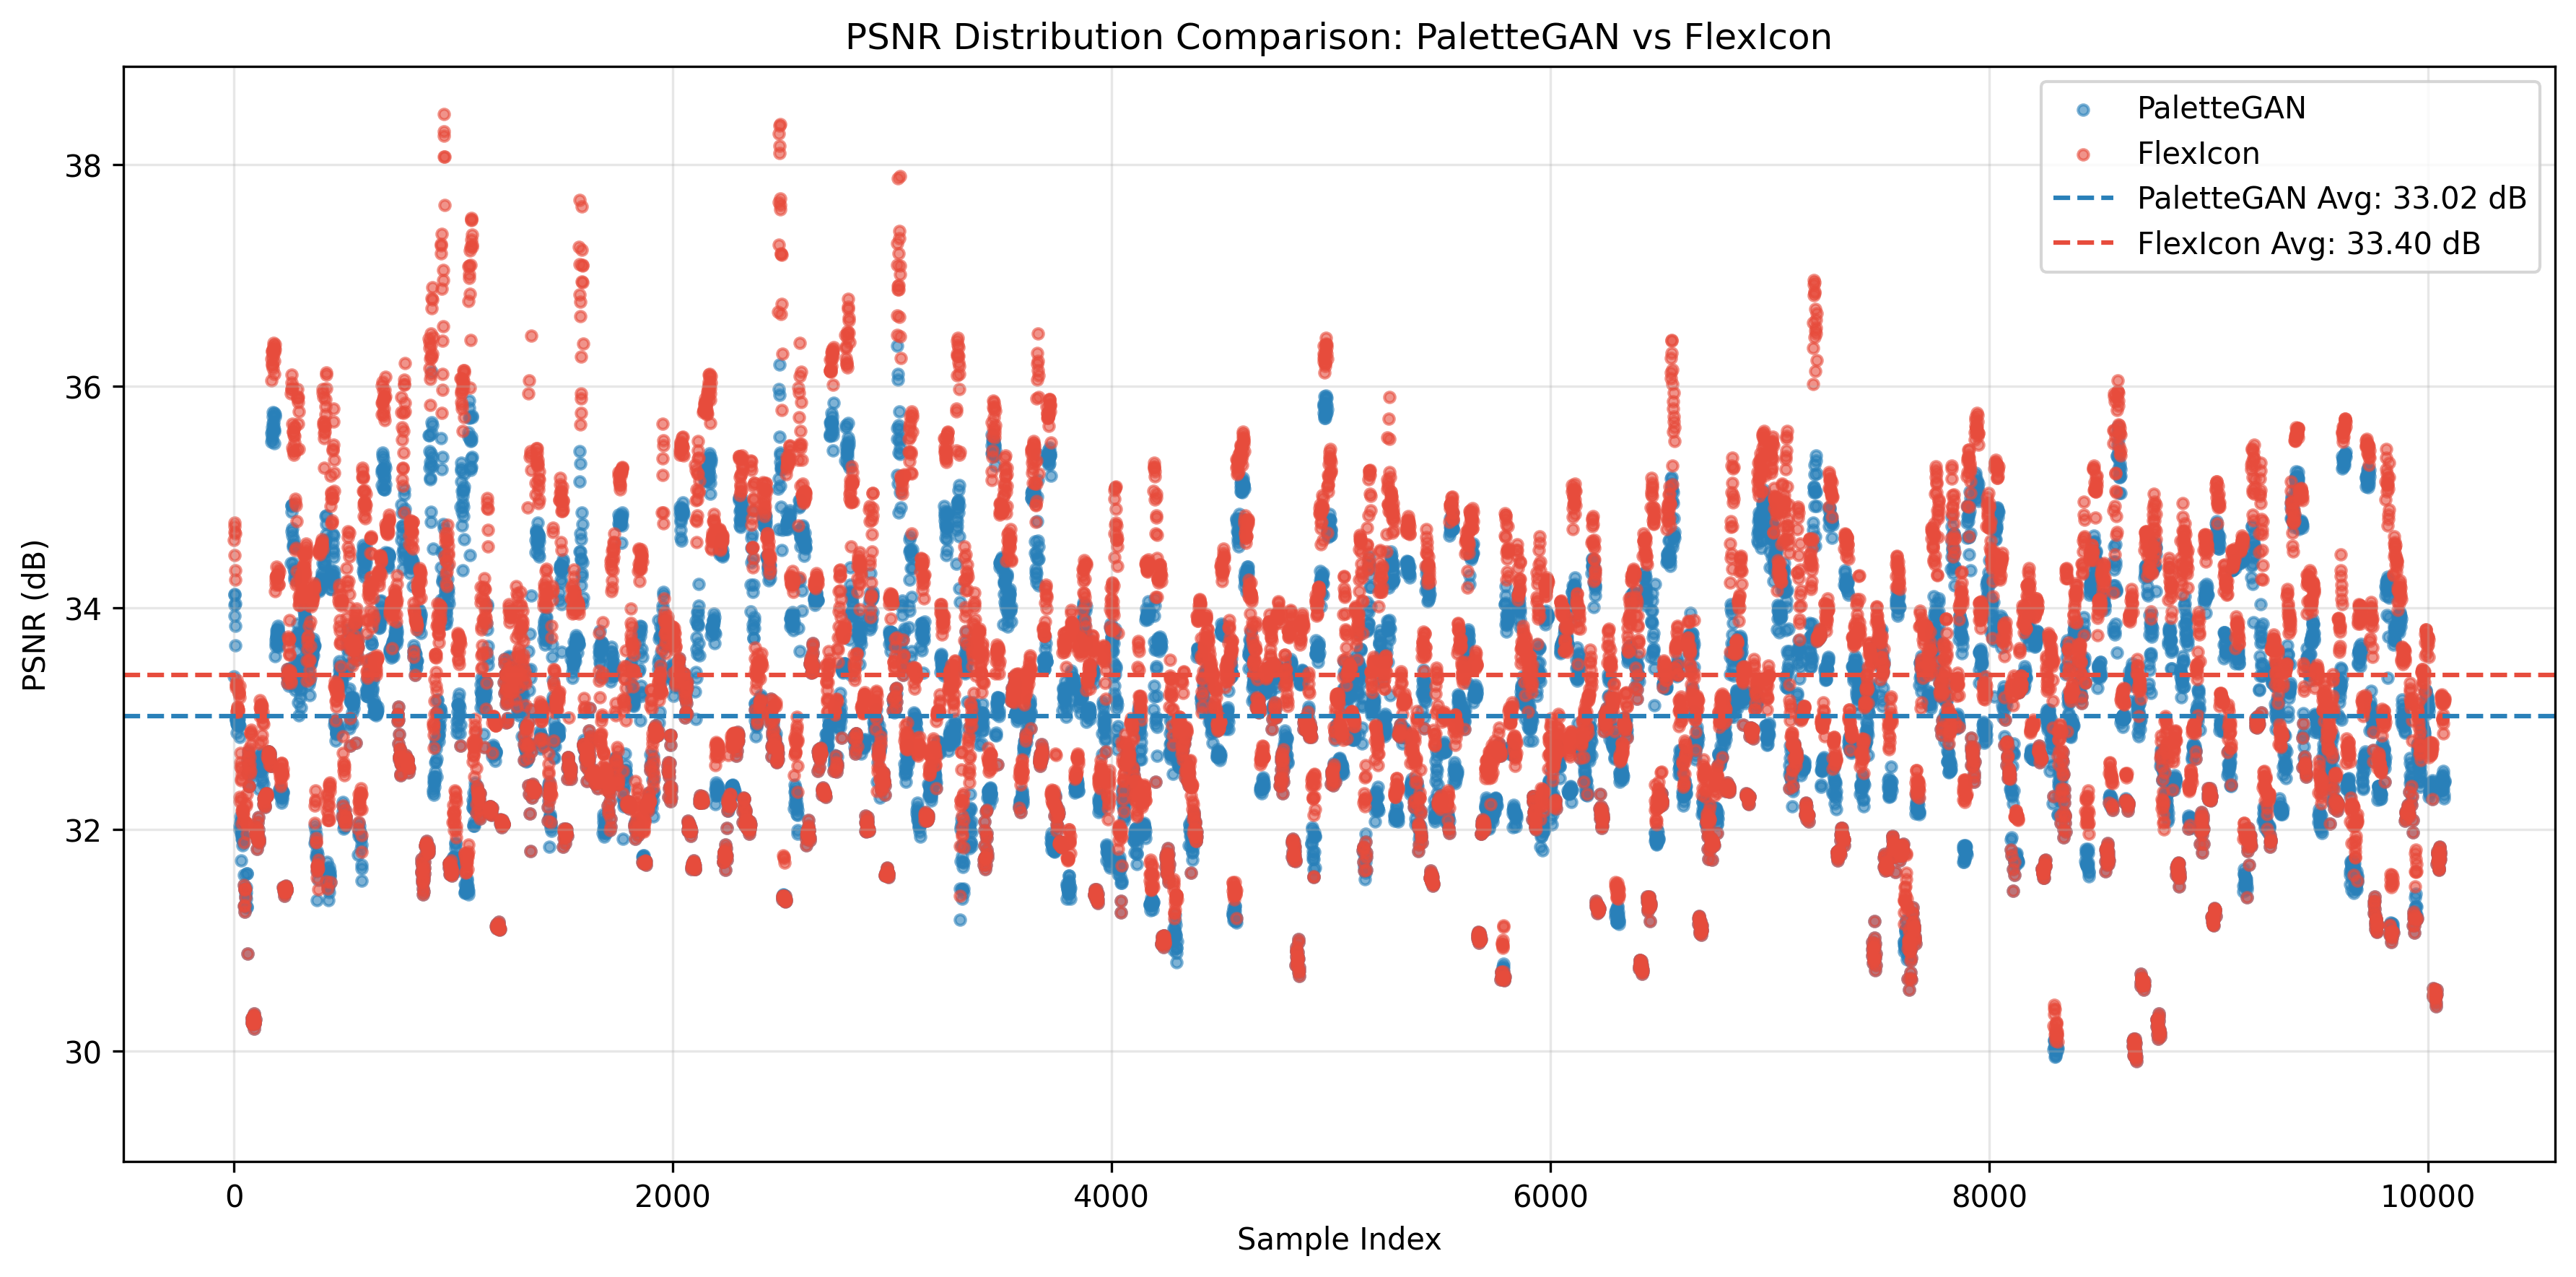

✅ 对比散点图已保存至：psnr_comparison.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------- 配置两个模型的结果文件 --------------------------
MODEL_A_PATH = "../pix2pix_code04/generated_results_dc_hed_contour_clean_/psnr_results.npz"   # PaletteGAN结果
MODEL_B_PATH = "../FlexIcon/test_output/batch_test/psnr_results.npz"     # FlexIcon结果
COMPARE_SAVE_PATH = "psnr_comparison.png"

# -------------------------- 加载数据 --------------------------
data_a = np.load(MODEL_A_PATH, allow_pickle=True)
data_b = np.load(MODEL_B_PATH, allow_pickle=True)
psnr_a = data_a["psnr"]
psnr_b = data_b["psnr"]
sample_idx = np.arange(len(psnr_a))

# 计算平均值
avg_a = np.mean(psnr_a)
avg_b = np.mean(psnr_b)

# -------------------------- 绘图 --------------------------
plt.rcParams['figure.dpi'] = 300
plt.figure(figsize=(12, 6))

# 绘制两个模型的散点
plt.scatter(sample_idx, psnr_a, color='#2980B9', alpha=0.6, s=12, label='PaletteGAN')
plt.scatter(sample_idx, psnr_b, color='#E74C3C', alpha=0.6, s=12, label='FlexIcon')

# 绘制平均值参考线
plt.axhline(avg_a, color='#2980B9', linestyle='--', linewidth=1.5,
            label=f'PaletteGAN Avg: {avg_a:.2f} dB')
plt.axhline(avg_b, color='#E74C3C', linestyle='--', linewidth=1.5,
            label=f'FlexIcon Avg: {avg_b:.2f} dB')

# 图表设置
plt.xlabel("Sample Index")
plt.ylabel("PSNR (dB)")
plt.title("PSNR Distribution Comparison: PaletteGAN vs FlexIcon")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(bottom=29)
plt.tight_layout()

# 保存图片
plt.savefig(COMPARE_SAVE_PATH)
plt.show()
print(f"✅ 对比散点图已保存至：{COMPARE_SAVE_PATH}")